In [1]:
import torch

from transformers import pipeline

/Users/matheus/Developer/exploring-hugging-face/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [3]:
sentiment_classify = pipeline("sentiment-analysis", "distilbert-base-uncased-finetuned-sst-2-english", device=device)

In [4]:
sentiment_classify([
    "I Loved this product",
    "I Hated this product"
])

[{'label': 'POSITIVE', 'score': 0.9998711347579956},
 {'label': 'NEGATIVE', 'score': 0.9997690320014954}]

In [5]:
from pysentimiento import create_analyzer

In [6]:
sentiment_classify = create_analyzer("sentiment", lang="pt")

sentiment_classify.model.to(torch.device("cpu"))

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64005, 768, padding_idx=1)
      (position_embeddings): Embedding(130, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [7]:
print(sentiment_classify.predict("Amei o produto"))
print(sentiment_classify.predict("É um produto"))
print(sentiment_classify.predict("Odiei o produto"))

AnalyzerOutput(output=POS, probas={POS: 0.991, NEU: 0.006, NEG: 0.002})
AnalyzerOutput(output=NEU, probas={NEU: 0.917, POS: 0.059, NEG: 0.025})
AnalyzerOutput(output=NEG, probas={NEG: 0.991, POS: 0.005, NEU: 0.004})


In [10]:
import ssl
import pandas as pd

ssl._create_default_https_context = ssl._create_unverified_context

df = pd.read_csv("https://raw.githubusercontent.com/vqrca/hugging_face/refs/heads/main/Dados/resenhas.csv")

In [12]:
df.head()

,ID,Resenha
0,24,"A fritadeira é sensacional, muito além do que ..."
1,733,"Após usar o produto, achei-o fácil e muito efi..."
2,865,"Muito funcional, prática e moderna."
3,809,"Boa, mas não das melhores pois a frente de vid..."
4,628,Eu comecei a usar e é bem espaçosa. Gostei poi...


In [14]:
sentiment_classify.model.to(torch.device("cpu"))

predict_results = sentiment_classify.predict(df["Resenha"].to_list())

Map: 100%|██████████| 36/36 [00:00<00:00, 4422.56 examples/s]


In [15]:
predict_results

[AnalyzerOutput(output=POS, probas={POS: 0.989, NEU: 0.009, NEG: 0.002}),
 AnalyzerOutput(output=POS, probas={POS: 0.670, NEU: 0.320, NEG: 0.011}),
 AnalyzerOutput(output=POS, probas={POS: 0.900, NEU: 0.097, NEG: 0.003}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.731, NEU: 0.259, POS: 0.010}),
 AnalyzerOutput(output=POS, probas={POS: 0.976, NEU: 0.021, NEG: 0.003}),
 AnalyzerOutput(output=POS, probas={POS: 0.956, NEU: 0.037, NEG: 0.007}),
 AnalyzerOutput(output=POS, probas={POS: 0.838, NEU: 0.093, NEG: 0.069}),
 AnalyzerOutput(output=POS, probas={POS: 0.990, NEU: 0.008, NEG: 0.002}),
 AnalyzerOutput(output=POS, probas={POS: 0.961, NEU: 0.036, NEG: 0.003}),
 AnalyzerOutput(output=POS, probas={POS: 0.990, NEU: 0.007, NEG: 0.003}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.896, NEU: 0.100, POS: 0.004}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.990, NEU: 0.008, POS: 0.003}),
 AnalyzerOutput(output=NEG, probas={NEG: 0.985, NEU: 0.011, POS: 0.003}),
 AnalyzerOutput(output=NEU, probas={NE

In [22]:
df.loc[:, "Prediction"] = [out.output for out in predict_results]

In [19]:
output_pos = sum([1 for pred in predict_results if pred.output == "POS"]) / len(predict_results) * 100
output_neu = sum([1 for pred in predict_results if pred.output == "NEU"]) / len(predict_results) * 100
output_neg = sum([1 for pred in predict_results if pred.output == "NEG"]) / len(predict_results) * 100

print(f"POS: {output_pos:.2f}%\nNEU: {output_neu:.2f}%\nNEG: {output_neg:.2f}%")

POS: 36.11%
NEU: 11.11%
NEG: 52.78%


In [20]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stopwords_pt = set(stopwords.words("portuguese"))


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matheus/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [37]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_text_pos = " ".join([row["Resenha"] for _, row in df.iterrows() if row["Prediction"] == "POS"])
all_text_pos = all_text_pos.replace(",", "").replace(".", "").split()
all_text_pos = " ".join([text for text in all_text_pos if text not in stopwords_pt])

all_text_neu = " ".join([row["Resenha"] for _, row in df.iterrows() if row["Prediction"] == "NEU"])
all_text_neu = all_text_neu.replace(",", "").replace(".", "").split()
all_text_neu = " ".join([text for text in all_text_neu if text not in stopwords_pt])

all_text_neg = " ".join([row["Resenha"] for _, row in df.iterrows() if row["Prediction"] == "NEG"])
all_text_neg = all_text_neg.replace(",", "").replace(".", "").split()
all_text_neg = " ".join([text for text in all_text_neg if text not in stopwords_pt])

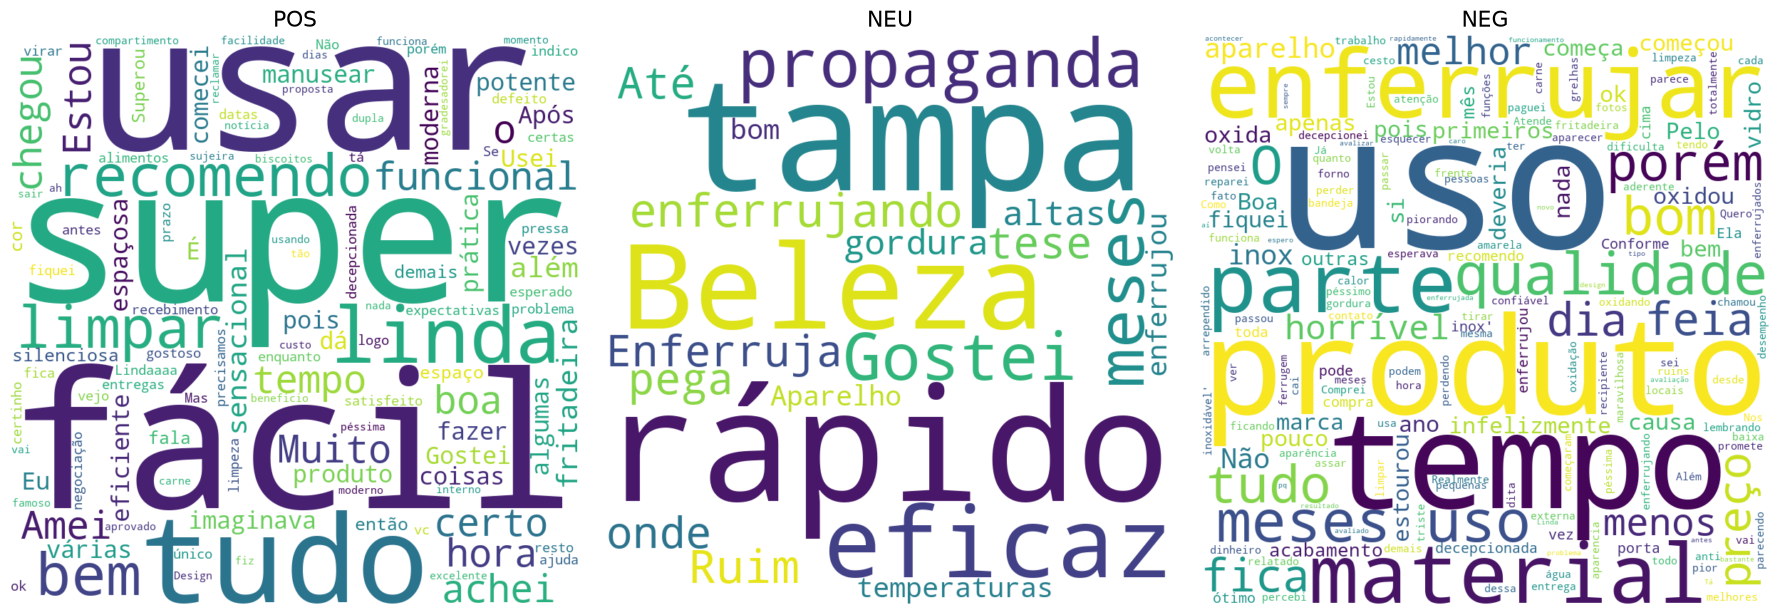

In [39]:
wc_pos = WordCloud(width=800, height=800, background_color="white").generate(all_text_pos)
wc_neu = WordCloud(width=800, height=800, background_color="white").generate(all_text_neu)
wc_neg = WordCloud(width=800, height=800, background_color="white").generate(all_text_neg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("POS", fontsize=16)
axes[0].axis("off")

axes[1].imshow(wc_neu, interpolation="bilinear")
axes[1].set_title("NEU", fontsize=16)
axes[1].axis("off")

axes[2].imshow(wc_neg, interpolation="bilinear")
axes[2].set_title("NEG", fontsize=16)
axes[2].axis("off")

plt.tight_layout()
plt.show()